In [1]:
# In this step we import libraries required for STL-10 loading, ResNet training, and Grad-CAM visualization.
# We also import helpers for stratified split, plotting, and reusable PyTorch utilities.
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
# In this step we define the global seed function and apply it.
# Same seed is set for python, numpy, and torch for reproducibility.
# So model comparisons become fair across different runs.
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: None (running on CPU)")


Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


# Part-A

In [3]:
# This cell downloads STL-10 and defines ImageNet normalization for ResNet-18.
# Separate train and evaluation transforms are used so augmentation stays train-only.
DATA_ROOT = "./stl10_data"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

STL10_CLASSES = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck",
]

base_train_dataset = datasets.STL10(root=DATA_ROOT, split="train", download=True)
train_dataset_full = datasets.STL10(root=DATA_ROOT, split="train", download=False, transform=train_tfms)
val_dataset_full = datasets.STL10(root=DATA_ROOT, split="train", download=False, transform=eval_tfms)
test_dataset = datasets.STL10(root=DATA_ROOT, split="test", download=True, transform=eval_tfms)

print(f"Full train samples: {len(train_dataset_full)}")
print(f"Test samples: {len(test_dataset)}")
print("Classes:", STL10_CLASSES)


Files already downloaded and verified
Files already downloaded and verified
Full train samples: 5000
Test samples: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [4]:
# Now we create stratified train-validation split using same class ratio.
# After split, dataloaders are built with chosen batch size.
BATCH_SIZE = 256

all_idx = np.arange(len(base_train_dataset))
all_labels = np.array(base_train_dataset.labels)

train_idx, val_idx = train_test_split(
    all_idx,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels,
    shuffle=True,
)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=2, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)} | Test samples: {len(test_dataset)}")


Train samples: 4000 | Validation samples: 1000 | Test samples: 8000


In [5]:
# This block defines one-epoch training function.
# It runs forward pass, loss, backward pass, and optimizer update.
# Finally it returns average train loss and train accuracy.
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()
    individual_loss_sum = 0
    correct_predicted = 0
    total_data = 0

    for each_inputs, each_targets in data_loader:
        each_inputs = each_inputs.to(DEVICE)
        each_targets = each_targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(each_inputs)
        loss = criterion(outputs, each_targets)
        loss.backward()
        optimizer.step()

        individual_loss_sum = individual_loss_sum + loss.item() * each_inputs.size(0)
        correct_predicted = correct_predicted + (torch.max(outputs, 1)[1] == each_targets).sum().item()
        total_data = total_data + each_targets.size(0)

    epoch_loss = individual_loss_sum / total_data
    epoch_accuracy = correct_predicted / total_data
    return epoch_loss, epoch_accuracy


In [6]:
# Here we define evaluation function with no gradient updates.
# Model is switched to eval mode and metrics are computed batch-wise.
def evaluate(model, data_loader, criterion):
    model.eval()
    individual_loss_sum = 0
    correct_predicted = 0
    total_data = 0

    with torch.no_grad():
        for each_inputs, each_targets in data_loader:
            each_inputs = each_inputs.to(DEVICE)
            each_targets = each_targets.to(DEVICE)

            outputs = model(each_inputs)
            loss = criterion(outputs, each_targets)

            individual_loss_sum = individual_loss_sum + loss.item() * each_inputs.size(0)
            correct_predicted = correct_predicted + (torch.max(outputs, 1)[1] == each_targets).sum().item()
            total_data = total_data + each_targets.size(0)

    epoch_loss = individual_loss_sum / total_data
    epoch_accuracy = correct_predicted / total_data
    return epoch_loss, epoch_accuracy


In [7]:
# This helper counts trainable parameters in any model.
# We use it here to verify that only the new classification head stays trainable.
def parameters_count(model):
    total_params = 0
    for p in model.parameters():
        if p.requires_grad:
            total_params = total_params + p.numel()
    return total_params


In [8]:
# This cell defines transfer learning model for STL-10 using pretrained ResNet-18.
# Feature extraction part comes from pretrained ResNet backbone and classifier part is replaced for 10 classes.
import torch
import torch.nn as nn
import torchvision.models as models

class STL10_ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        try:
            self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        except Exception:
            self.model = models.resnet18(pretrained=True)

        # 1) Freeze the whole pretrained backbone
        for param in self.model.parameters():
            param.requires_grad = False

        # 2) Replace final FC layer with a new classifier for STL-10
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

        # make sure new classifier is trainable
        for param in self.model.fc.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

    def train(self, mode=True):
        super().train(mode)

        # keep frozen backbone in eval mode so BatchNorm stats do not update
        for module in self.model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

        return self

resnet_model = STL10_ResNet18(num_classes=len(STL10_CLASSES)).to(DEVICE)
trainable_params = parameters_count(resnet_model)
print("Trainable params:", trainable_params)
print(resnet_model)

Trainable params: 5130
STL10_ResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum

In [9]:
# Now we configure Part A loss, optimizer, and lr scheduler.
# Training loop runs for full epochs and tracks train and validation metrics.
# Printed logs help monitor learning progress after freezing pretrained features.
loss_function_resnet = nn.CrossEntropyLoss()
EPOCHS = 20

resnet_optimizer = torch.optim.Adam(
    resnet_model.model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

resnet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

resnet_train_losses = []
resnet_val_losses = []
resnet_train_accs = []
resnet_val_accs = []

print("||Task 2 Part A: ResNet-18 Head Training||")

for each_epoch in range(EPOCHS):

    training_loss, training_accuracy = train_one_epoch(
        resnet_model, train_loader, loss_function_resnet, resnet_optimizer
    )
    validation_loss, validation_accuracy = evaluate(
        resnet_model, val_loader, loss_function_resnet
    )
    resnet_scheduler.step(validation_accuracy)

    resnet_train_losses.append(training_loss)
    resnet_val_losses.append(validation_loss)
    resnet_train_accs.append(training_accuracy)
    resnet_val_accs.append(validation_accuracy)

    current_lr = resnet_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{each_epoch+1}/{EPOCHS}] | LR {current_lr:.6f} | "
        f"Train Loss {training_loss:.5f}, Train Acc {training_accuracy:.5f} | "
        f"Val Loss {validation_loss:.5f}, Val Acc {validation_accuracy:.5f}"
    )


||Task 2 Part A: ResNet-18 Head Training||
Epoch [1/20] | LR 0.001000 | Train Loss 1.67503, Train Acc 0.51400 | Val Loss 1.03058, Val Acc 0.82200
Epoch [2/20] | LR 0.001000 | Train Loss 0.72562, Train Acc 0.89125 | Val Loss 0.52620, Val Acc 0.92500
Epoch [3/20] | LR 0.001000 | Train Loss 0.42077, Train Acc 0.93200 | Val Loss 0.37080, Val Acc 0.93100
Epoch [4/20] | LR 0.001000 | Train Loss 0.31376, Train Acc 0.94300 | Val Loss 0.30574, Val Acc 0.94300
Epoch [5/20] | LR 0.001000 | Train Loss 0.26505, Train Acc 0.94650 | Val Loss 0.26908, Val Acc 0.94500
Epoch [6/20] | LR 0.001000 | Train Loss 0.23041, Train Acc 0.95275 | Val Loss 0.24586, Val Acc 0.94500
Epoch [7/20] | LR 0.001000 | Train Loss 0.20929, Train Acc 0.95425 | Val Loss 0.22947, Val Acc 0.94400
Epoch [8/20] | LR 0.001000 | Train Loss 0.19151, Train Acc 0.95425 | Val Loss 0.21600, Val Acc 0.94600
Epoch [9/20] | LR 0.001000 | Train Loss 0.17816, Train Acc 0.95975 | Val Loss 0.20648, Val Acc 0.94900
Epoch [10/20] | LR 0.001000 | 

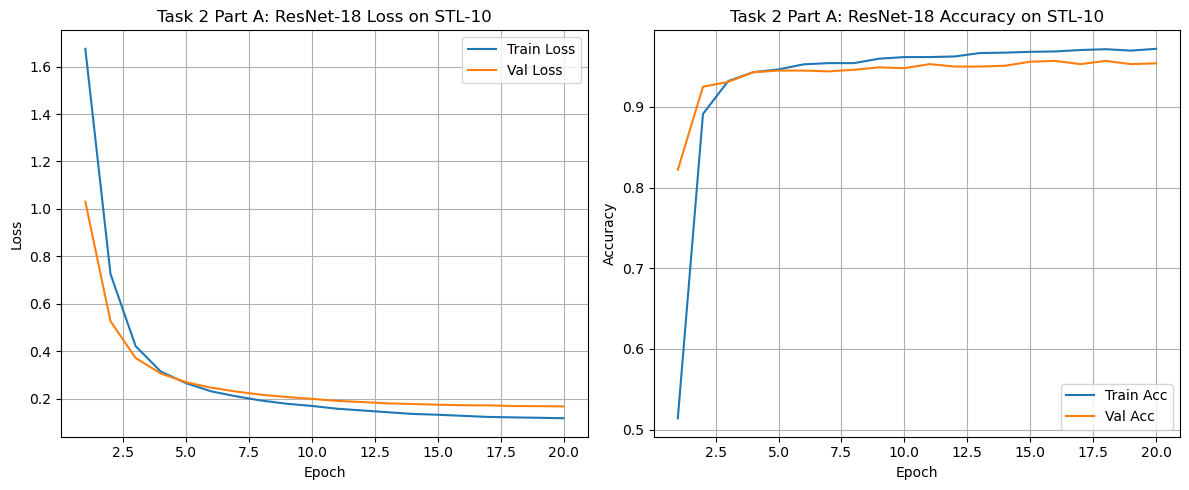

In [10]:
# This block plots Part A training and validation curves.
# Both loss and accuracy trends are shown side by side.
epochs_range_resnet = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_resnet, resnet_train_losses, label="Train Loss")
plt.plot(epochs_range_resnet, resnet_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 2 Part A: ResNet-18 Loss on STL-10")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_resnet, resnet_train_accs, label="Train Acc")
plt.plot(epochs_range_resnet, resnet_val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Task 2 Part A: ResNet-18 Accuracy on STL-10")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [11]:
# Here we run final evaluation on train, validation, and test loaders.
# These metrics can be used directly in the assignment report.
resnet_train_loss, resnet_train_acc = evaluate(resnet_model, train_loader, loss_function_resnet)
resnet_val_loss, resnet_val_acc = evaluate(resnet_model, val_loader, loss_function_resnet)
resnet_test_loss, resnet_test_acc = evaluate(resnet_model, test_loader, loss_function_resnet)

print(f"ResNet Train Loss: {resnet_train_loss:.5f}")
print(f"ResNet Train Acc : {resnet_train_acc:.5f}")
print(f"ResNet Val Loss  : {resnet_val_loss:.5f}")
print(f"ResNet Val Acc   : {resnet_val_acc:.5f}")
print(f"ResNet Test Loss : {resnet_test_loss:.5f}")
print(f"ResNet Test Acc  : {resnet_test_acc:.5f}")


ResNet Train Loss: 0.11701
ResNet Train Acc : 0.97025
ResNet Val Loss  : 0.16695
ResNet Val Acc   : 0.95400
ResNet Test Loss : 0.16783
ResNet Test Acc  : 0.95037


# Part-B

In [12]:
# This helper collects predictions from the STL-10 test loader in original order.
# Another helper converts normalized images back into displayable RGB format.
# Both helpers are reused in the Grad-CAM visualization block below.
def collect_predictions(model, data_loader):
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for each_inputs, each_targets in data_loader:
            each_inputs = each_inputs.to(DEVICE)
            outputs = model(each_inputs)
            predicted_labels = torch.argmax(outputs, dim=1)

            all_predictions.extend(predicted_labels.cpu().tolist())
            all_targets.extend(each_targets.tolist())

    return all_predictions, all_targets


def denormalize_stl10_image(image_tensor, mean, std):
    image = image_tensor.detach().cpu().clone()
    mean_tensor = torch.tensor(mean, dtype=image.dtype).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=image.dtype).view(3, 1, 1)

    image = image * std_tensor + mean_tensor
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


In [13]:
# This cell selects 2 correct and 2 incorrect STL-10 test samples.
# These samples will later be used for Grad-CAM visualization and analysis.
all_pred, all_true = collect_predictions(resnet_model, test_loader)

correct_pool = [idx for idx, (pred, true) in enumerate(zip(all_pred, all_true)) if pred == true]
incorrect_pool = [idx for idx, (pred, true) in enumerate(zip(all_pred, all_true)) if pred != true]

selected_correct = random.sample(correct_pool, 2)
selected_incorrect = random.sample(incorrect_pool, 2)
selected_indices = selected_correct + selected_incorrect

print("Selected correct indices:", selected_correct)
print("Selected incorrect indices:", selected_incorrect)

Selected correct indices: [5517, 958]
Selected incorrect indices: [355, 7691]


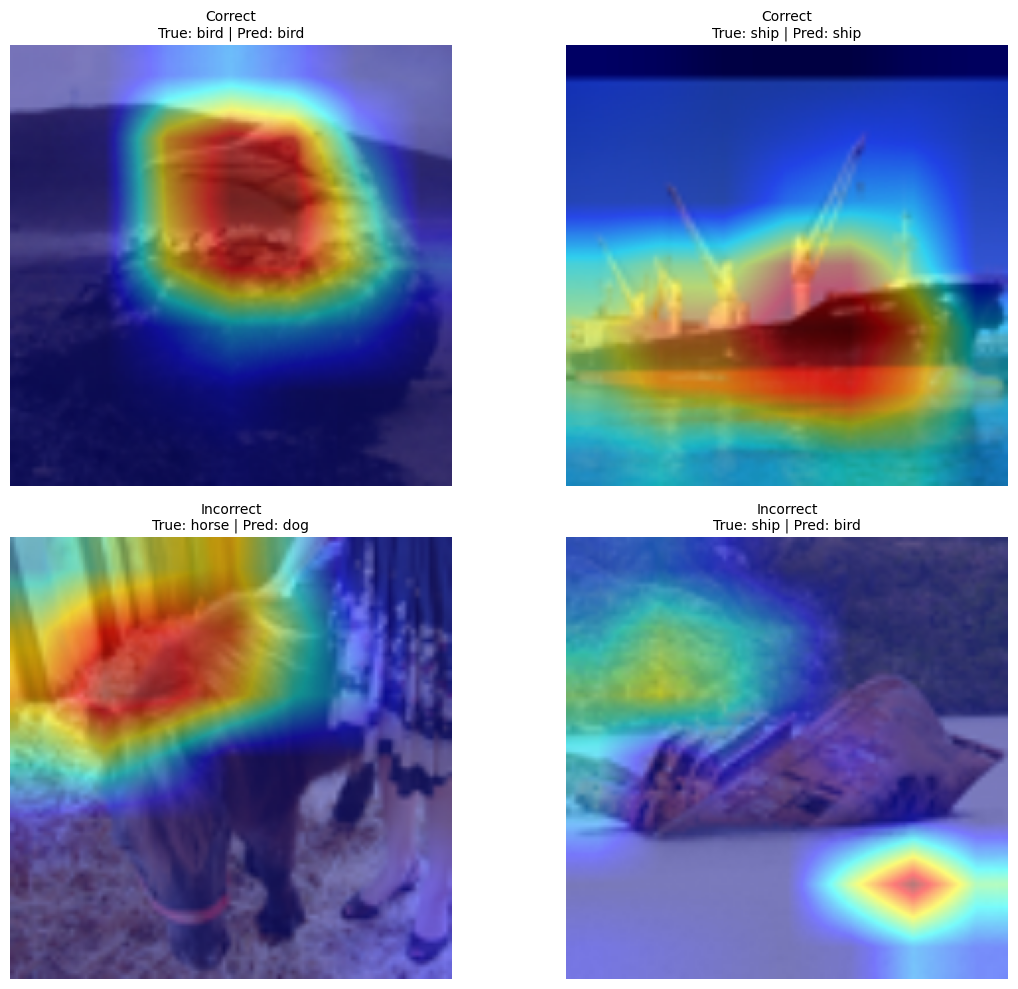

In [14]:
# This cell generates Grad-CAM heatmaps using the library on the final ResNet block.
# Input tensor is marked to require gradients so Grad-CAM can backprop through the frozen backbone.
target_layers = [resnet_model.model.layer4[-1]]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

with GradCAM(model=resnet_model, target_layers=target_layers) as cam:

    for ax, sample_idx in zip(axes.flatten(), selected_indices):
        image_tensor, true_label = test_dataset[sample_idx]
        input_tensor = image_tensor.unsqueeze(0).to(DEVICE)
        input_tensor.requires_grad_(True)

        output_logits = resnet_model(input_tensor)
        predicted_label = torch.argmax(output_logits, dim=1).item()
        targets = [ClassifierOutputTarget(predicted_label)]

        resnet_model.zero_grad()
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

        rgb_image = denormalize_stl10_image(image_tensor, IMAGENET_MEAN, IMAGENET_STD)
        cam_overlay = show_cam_on_image(rgb_image.astype(np.float32), grayscale_cam, use_rgb=True)

        correctness = "Correct" if predicted_label == true_label else "Incorrect"

        ax.imshow(cam_overlay)
        ax.set_title(
            f"{correctness}\nTrue: {STL10_CLASSES[true_label]} | Pred: {STL10_CLASSES[predicted_label]}",
            fontsize=10
        )
        ax.axis("off")

plt.tight_layout()
plt.show()
